# Random Forest Classifier - Breast Cancer Detection
**Dataset:** Breast Cancer Wisconsin (569 samples, 32 features)

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


## Importing (Reading) Datasets

In [2]:
df = pd.read_csv('data.csv')
print(df.shape)
df.head()


(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Assigning Dependent and Independent Variables

In [3]:
df = df.drop(columns=['Unnamed: 32'], errors='ignore')
x = df.drop(columns=['id', 'diagnosis']).values
y = df['diagnosis'].values
print('x shape:', x.shape)
print('y unique:', np.unique(y))


x shape: (569, 30)
y unique: ['B' 'M']


## Splitting Dataset into Training and Testing Dataset

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=41)


## Preprocessing Data with StandardScaler

In [5]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


## Fitting the Model - Random Forest Classifier

In [6]:
model = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


## Evaluation Metrics

In [7]:
print('Random Forest Classifier')
conf_mat = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:\n', conf_mat)
acc = accuracy_score(y_test, y_pred)
print('Accuracy Score:', acc)
print('Accuracy in Percentage:', int(acc * 100), '%')
print('\n', classification_report(y_pred, y_test))


Random Forest Classifier

Confusion Matrix:
 [[108   2]
 [  0  61]]
Accuracy Score: 0.9883040935672515
Accuracy in Percentage: 98 %

               precision    recall  f1-score   support

           B       0.98      1.00      0.99       108
           M       1.00      0.97      0.98        63

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



## Confusion Matrix Heatmap

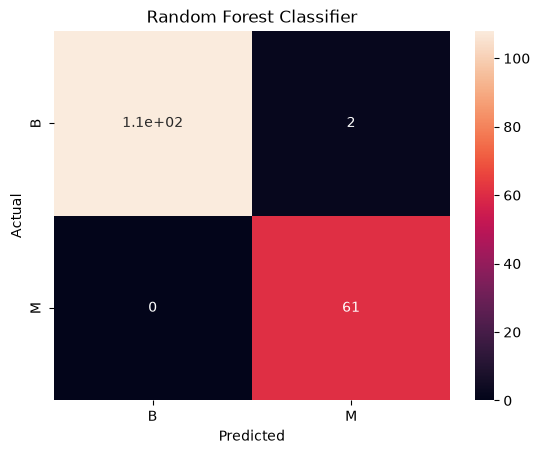

In [8]:
conf_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(conf_df, annot=True).set(title='Random Forest Classifier')
plt.show()


## Visualizing One Decision Tree from the Forest

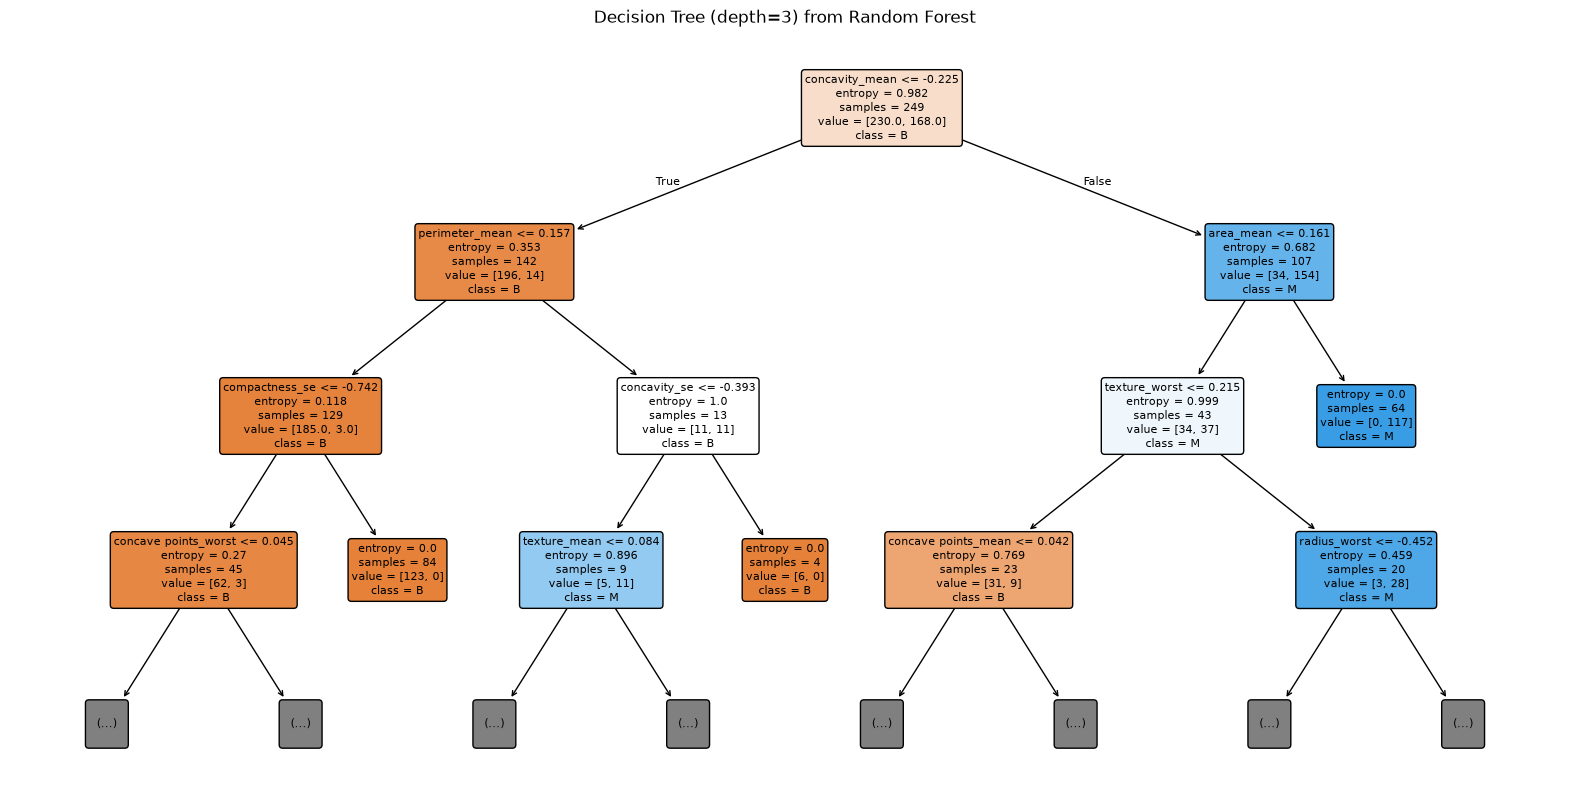

In [9]:
from sklearn import tree
import matplotlib.pyplot as plt

feature_names = df.drop(columns=['id', 'diagnosis']).columns.tolist()
class_names = np.unique(y).tolist()

fig, ax = plt.subplots(figsize=(20, 10))
tree.plot_tree(model.estimators_[0],
               feature_names=feature_names,
               class_names=class_names,
               filled=True,
               rounded=True,
               max_depth=3,
               ax=ax)
plt.title('Decision Tree (depth=3) from Random Forest')
plt.show()
